In [188]:


import torch
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, accuracy_score
import numpy as np
import matplotlib.pyplot as plt # Optional, for plotting if needed



In [301]:
from event_tokenizer import tokenizer, tokenizer_encode, tokenizer_decode, vocab_size


In [195]:

skip_inputid = 148
assert tokenizer['CN'] == skip_inputid, tokenizer['CN']

In [205]:
import torch.nn as nn

class CLIPForCausalLM(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.clip_text = CLIPTextModel(config)
        self.lm_head = nn.Linear(config.hidden_size, config.vocab_size, bias=False)
        self.lm_head.weight = self.clip_text.text_model.embeddings.token_embedding.weight

    def forward(self, input_ids, attention_mask=None, labels=None):
        outputs = self.clip_text(input_ids=input_ids, attention_mask=attention_mask)
        logits = self.lm_head(outputs.last_hidden_state)
        
        loss = None
        if labels is not None:
            shift_logits = logits[..., :-1, :].contiguous()
            shift_labels = labels[..., 1:].contiguous()
            
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(shift_logits[shift_labels!=skip_inputid].view(-1, shift_logits.size(-1)), shift_labels[shift_labels!=skip_inputid].view(-1))

        return {"loss": loss, "logits": logits}

In [192]:
list(tokenizer.keys())[:10], list(tokenizer.values())[:10]

([' ',
  '-',
  '<|endoftext|>',
  '<|startoftext|>',
  'A00',
  'A02',
  'A03',
  'A04',
  'A07',
  'A08'],
 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [193]:

tokenizer = CLIPTokenizer("icd10_tokenizer_base/pure_vocab.json", "icd10_tokenizer_base/merges.txt")
tokenizer('A02-A04-A04-A04-A04-A04-A04-A04-A04-A04-A04-A04-A04-A04-A04-A04-A04', max_length=30,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )['attention_mask'].dtype

NameError: name 'CLIPTokenizer' is not defined

In [113]:
torch.tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0]]).dtype

torch.int64

In [111]:
torch.tensor([[3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
         2, 2, 2, 2, 2, 2]]).shape

torch.Size([1, 30])

{'input_ids': [3, 2, 2, 2, 2], 'attention_mask': [1, 1, 1, 1, 1]}

In [302]:
import os
from transformers import CLIPTokenizer, CLIPTextConfig, CLIPTextModel
from event_model import CLIPForCausalLM
device = 'cuda:5'

config = CLIPTextConfig(
    vocab_size=len(tokenizer),
    hidden_size=512,       
    intermediate_size=1024, 
    num_hidden_layers=16,
    num_attention_heads=8,
    max_position_embeddings=200
)

model = CLIPForCausalLM(config).to(device)
# model.load_state_dict(torch.load('icd10_tokenizer_simple/text_model_skipCN.pth'))
model.load_state_dict({k.replace('module.', ''): v for k,v in torch.load('icd10_tokenizer_posid/text_model.pth').items()})
model.eval()

CLIPForCausalLM(
  (clip_text): CLIPTextModel(
    (text_model): CLIPTextTransformer(
      (embeddings): CLIPTextEmbeddings(
        (token_embedding): Embedding(1446, 512)
        (position_embedding): Embedding(200, 512)
      )
      (encoder): CLIPEncoder(
        (layers): ModuleList(
          (0-15): 16 x CLIPEncoderLayer(
            (self_attn): CLIPAttention(
              (k_proj): Linear(in_features=512, out_features=512, bias=True)
              (v_proj): Linear(in_features=512, out_features=512, bias=True)
              (q_proj): Linear(in_features=512, out_features=512, bias=True)
              (out_proj): Linear(in_features=512, out_features=512, bias=True)
            )
            (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
            (mlp): CLIPMLP(
              (activation_fn): QuickGELUActivation()
              (fc1): Linear(in_features=512, out_features=1024, bias=True)
              (fc2): Linear(in_features=1024, out_features=512, bi

In [303]:

with open('icd10_val_split.txt', 'r') as f:
    test_data = f.read().split('\n')
# test_data = []
# for icd_code in icd_codes:
#     test_data.append(icd_code.split(' '))



In [304]:
from torch.utils.data import Dataset, DataLoader
batch_size = 64
class ICDDataset(Dataset):
    def __init__(self, file_path, tokenizer):
        with open(file_path, 'r') as f:
            self.lines = [line.strip() for line in f.readlines()]
        # self.tokenizer = tokenizer
        self.max_len = 200

    def __len__(self):
        return len(self.lines)

    def __getitem__(self, idx):
        input_ids, seq_posids = tokenizer_encode(self.lines[idx])
        input_ids = torch.LongTensor(input_ids)
        seq_posids = torch.LongTensor(seq_posids)
        attn_mask = torch.ones_like(input_ids)
        seq_posids = torch.cat([seq_posids, torch.zeros(self.max_len-len(seq_posids))]).long()
        input_ids = torch.cat([input_ids, torch.zeros(self.max_len-len(input_ids))]).long()
        attn_mask = torch.cat([attn_mask, torch.zeros(self.max_len-len(attn_mask))]).long()
        return {
            "input_ids": input_ids,
            "seq_posids": seq_posids,
            "attention_mask": attn_mask,
            "labels": input_ids.clone()
        }

val_dataset = ICDDataset('icd10_val_split.txt', tokenizer)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [305]:

class ICDDataset(Dataset):
    def __init__(self, file_path, tokenizer):
        with open(file_path, 'r') as f:
            self.lines = [line.strip() for line in f.readlines()]
        # self.tokenizer = tokenizer
        self.max_len = 200

    def __len__(self):
        return len(self.lines)

    def __getitem__(self, idx):
        input_ids, seq_posids = tokenizer_encode(self.lines[idx])
        input_ids = torch.LongTensor(input_ids)
        seq_posids = torch.LongTensor(seq_posids)
        attn_mask = torch.ones_like(input_ids)
        seq_posids = torch.cat([seq_posids, torch.zeros(self.max_len-len(seq_posids))]).long()
        input_ids = torch.cat([input_ids, torch.zeros(self.max_len-len(input_ids))]).long()
        attn_mask = torch.cat([attn_mask, torch.zeros(self.max_len-len(attn_mask))]).long()
        return {
            "input_ids": input_ids,
            "seq_posids": seq_posids,
            "attention_mask": attn_mask,
            "labels": input_ids.clone()
        }

val_dataset = ICDDataset('icd10_val_split.txt', tokenizer)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [306]:
len(val_dataset)

3425

In [678]:
# source: https://www.medrxiv.org/content/medrxiv/early/2022/02/17/2022.02.16.22271085/DC1/embed/media-1.pdf?download=true
brain_code_str='''A81 
E71, E75, E75, E75 
F01, F02, F03, F04, F10, F10,
F10, F10, F13, F13, F13,
F13, F18, F18
G10, G20, G30, G23, G31, G31
R41'''
brain_codes = []
for line in brain_code_str.split('\n'):
    brain_codes.extend([i for i in line.split(', ')])
brain_codes = np.unique(brain_codes)
print(brain_codes)
# source: https://www.cms.gov/medicare/coding/icd10/downloads/icd10clinicalconceptscardiology1.pdf
heart_codes = ['R00', 'I48', 'I49', 'I20', 'R07', 'I34', 'I35', 'I10', 'I50', 'I21', 'I22', 'I23', 'I25', 'R55']
kidney_codes = [f'N{i:02d}' for i in range(100)]
liver_codes = [f'K{i:02d}' for i in range(70, 78, 1)]

brain_codes = [tokenizer[c.item()] for c in brain_codes if c.item() in tokenizer]
heart_codes = [tokenizer[c] for c in heart_codes if c in tokenizer]
kidney_codes = [tokenizer[c] for c in kidney_codes if c in tokenizer]
liver_codes = [tokenizer[c] for c in liver_codes if c in tokenizer]

['A81 ' 'E71' 'E75' 'E75 ' 'F01' 'F02' 'F03' 'F04' 'F10' 'F10,' 'F13'
 'F13,' 'F18' 'G10' 'G20' 'G23' 'G30' 'G31' 'R41']


In [313]:
from tqdm import tqdm
"""
Evaluates the model on next-token prediction using:
1. Standard Accuracy (Top-1)
2. Calibration AUC (Relationship between Confidence and Correctness)
"""
model.eval()

# Store predictions for metrics
all_gt = []   # 1 if prediction matches target, 0 otherwise
all_pred_score = []   # The probability score of the predicted token
all_pred_id = []   
all_seq_posid = []

print(f"Evaluating on {len(test_data)} sequences...")
print("-" * 50)

with torch.no_grad():
    for batch in tqdm(val_dataloader):
        # input_ids = batch["input_ids"].to(device)
        # mask = batch["attention_mask"].to(device)
        # labels = batch["labels"].to(device)
        # labels = labels[:, 2:]
        # outputs = model(input_ids, mask)
        
        seq_posids = batch["seq_posids"].to(device)
        input_ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)
        

        output = model(input_ids, seq_posids, mask, labels)

        
        logits = output["logits"][:, 1:-1] # (1, seq_len, vocab)
        _, pred_ids = F.softmax(logits, dim=-1).max(-1)
        labels = input_ids[:, 2:]
        seq_mask = (labels>3).detach().cpu()
        seq_posid = seq_posids[:, 2:][seq_mask]
        input_id = input_ids[:, 1:-1][seq_mask]
        logits = logits[seq_mask]
        pred_ids = pred_ids[seq_mask]
        labels = labels[seq_mask]        
        
        # logits = outputs["logits"][:, 1:-1] # (1, seq_len, vocab)
        # _, pred_ids = F.softmax(logits, dim=-1).max(-1)
        # # seq_posid = torch.arange(logits.shape[1])[None].repeat(len(logits), 1).to(logits.device)
        # # seq_mask = (labels!=skip_inputid)&(labels>3)
        # seq_mask = labels>3
        # seq_posid = seq_posid[seq_mask]
        # logits = logits[seq_mask]
        # pred_ids = pred_ids[seq_mask]
        # labels = labels[seq_mask]        
        all_seq_posid.append(seq_posid)
        all_gt.append(labels.detach().cpu())
        all_pred_score.append(logits.detach().cpu())
        all_pred_id.append(pred_ids.detach().cpu())
all_gt = torch.cat(all_gt)
all_pred_score = torch.cat(all_pred_score)
all_pred_id = torch.cat(all_pred_id)
all_seq_posid = torch.cat(all_seq_posid)


Evaluating on 3425 sequences...
--------------------------------------------------


100%|███████████████████████████████████████████| 54/54 [00:08<00:00,  6.69it/s]


{'input_ids': tensor([[  3, 148, 148,  ...,   0,   0,   0],
         [  3, 148, 148,  ...,   0,   0,   0],
         [  3, 148, 148,  ...,   0,   0,   0],
         ...,
         [  3, 148, 148,  ...,   0,   0,   0],
         [  3, 148, 148,  ...,   0,   0,   0],
         [  3, 148, 148,  ...,   0,   0,   0]]),
 'seq_posids': tensor([[0, 1, 2,  ..., 0, 0, 0],
         [0, 1, 2,  ..., 0, 0, 0],
         [0, 1, 2,  ..., 0, 0, 0],
         ...,
         [0, 1, 2,  ..., 0, 0, 0],
         [0, 1, 2,  ..., 0, 0, 0],
         [0, 1, 2,  ..., 0, 0, 0]]),
 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         ...,
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0],
         [1, 1, 1,  ..., 0, 0, 0]]),
 'labels': tensor([[  3, 148, 148,  ...,   0,   0,   0],
         [  3, 148, 148,  ...,   0,   0,   0],
         [  3, 148, 148,  ...,   0,   0,   0],
         ...,
         [  3, 148, 148,  ...,   0,   0,

In [308]:
import warnings
warnings.filterwarnings("ignore")

In [677]:
auc_list

[0.804658062882127, 0.9074527080298183, 0.9634616495257559, 0.9405129397337566]

In [680]:
brain_codes

[257, 269, 270, 271, 275, 325, 327, 330, 331, 989]

In [684]:
from sklearn import metrics
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from tqdm import tqdm
all_gt = all_gt.cpu()
all_pred_score = all_pred_score.cpu()
all_pred_id = all_pred_id.cpu()
labeln = []
labels = all_gt.unique().tolist()
auc_list = []
prec_list = []
rec_list = []
f1_list = []
pred_idx = all_pred_score.argmax(-1)
for labeli in tqdm(liver_codes):
    gt = (all_gt == labeli).float()
    if gt.sum() < 2: continue
    pred_score = all_pred_score[:, labeli]
    pred = (pred_idx==labeli).float()
    auc = metrics.roc_auc_score(gt, pred_score)
    prec = precision_score(gt, pred)
    rec = recall_score(gt, pred)
    f1 = f1_score(gt, pred)
    prec_list.append(prec)
    rec_list.append(rec)
    f1_list.append(f1)
    auc_list.append(auc)
    labeln.append(gt.sum())
print(np.mean(f1_list), np.mean(auc_list))
    # break
# auc, tokenizer_decode(all_gt.unique().tolist())[labeli]

100%|█████████████████████████████████████████████| 7/7 [00:00<00:00, 10.13it/s]

0.0061162079510703364 0.8559110287759281


In [238]:
from sklearn import metrics
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from tqdm import tqdm
all_gt = all_gt.cpu()
all_pred_score = all_pred_score.cpu()
all_pred_id = all_pred_id.cpu()
labeln = []
labels = all_gt.unique().tolist()
auc_list = []
prec_list = []
rec_list = []
f1_list = []
pred_idx = all_pred_score.argmax(-1)
for labeli in tqdm(all_gt.unique()):
    gt = (all_gt == labeli).float()
    if gt.sum() < 2: continue
    pred_score = all_pred_score[:, labeli]
    pred = (pred_idx==labeli).float()
    auc = metrics.roc_auc_score(gt, pred_score)
    prec = precision_score(gt, pred)
    rec = recall_score(gt, pred)
    f1 = f1_score(gt, pred)
    prec_list.append(prec)
    rec_list.append(rec)
    f1_list.append(f1)
    auc_list.append(auc)
    labeln.append(gt.sum())
    # break
# auc, tokenizer_decode(all_gt.unique().tolist())[labeli]

100%|███████████████████████████████████████| 1110/1110 [01:23<00:00, 13.30it/s]


In [655]:
np.mean(rec_list), np.mean(prec_list), np.mean(f1_list), np.mean(auc_list)

(np.float64(0.019479468272398364),
 np.float64(0.025246543075087374),
 np.float64(0.016656531576563712),
 np.float64(0.8311021895158991))

In [241]:
labeln = np.array(labeln)
labels = np.array(labels)
auc_list = np.array(auc_list)
prec_list = np.array(prec_list)
rec_list = np.array(rec_list)
f1_list = np.array(f1_list)

In [242]:
labeln.max()

np.float32(190187.0)

In [656]:
min_labeln = 200
sum(labeln>min_labeln)

np.int64(39)

In [658]:
np.mean(rec_list[labeln>min_labeln]), np.mean(prec_list[labeln>min_labeln]), np.mean(f1_list[labeln>min_labeln]), np.mean(auc_list[labeln>min_labeln]), np.std(rec_list[labeln>min_labeln]), np.std(prec_list[labeln>min_labeln]), np.std(f1_list[labeln>min_labeln]), np.std(auc_list[labeln>min_labeln])

(np.float64(0.12295448102570483),
 np.float64(0.15127831915222986),
 np.float64(0.11914899237654346),
 np.float64(0.8867487209764378),
 np.float64(0.1790684893075277),
 np.float64(0.1626700270048894),
 np.float64(0.16278535121865775),
 np.float64(0.0604662875960843))

In [323]:
(rec_list[labeln>min_labeln]), (prec_list[labeln>min_labeln]), (f1_list[labeln>min_labeln]), (auc_list[labeln>min_labeln])

(array([0.98921062, 0.23913043, 0.06286837, 0.27937916, 0.50717703,
        0.03921569, 0.07674419, 0.26096033, 0.17789757, 0.104811  ,
        0.00887574, 0.10498688, 0.        , 0.11953353, 0.1216992 ,
        0.12526096, 0.01408451, 0.11842105]),
 array([0.89453064, 0.23692308, 0.07748184, 0.15799373, 0.2973352 ,
        0.10687023, 0.05418719, 0.24319066, 0.27385892, 0.1037415 ,
        0.08823529, 0.12307692, 0.        , 0.29927007, 0.16383308,
        0.52631579, 0.23333333, 0.2625    ]),
 array([0.93949124, 0.23802164, 0.06941432, 0.20184221, 0.37488948,
        0.05737705, 0.06352262, 0.25176234, 0.21568627, 0.1042735 ,
        0.01612903, 0.11331445, 0.        , 0.17083333, 0.13965744,
        0.20236088, 0.02656546, 0.16321244]),
 array([0.92680102, 0.85415707, 0.84238153, 0.88685739, 0.9607852 ,
        0.87686813, 0.85555047, 0.89959949, 0.94400199, 0.90638376,
        0.83857601, 0.86678931, 0.8336819 , 0.9815474 , 0.96649173,
        0.97569191, 0.96233368, 0.97958423]))

<Axes: ylabel='Density'>

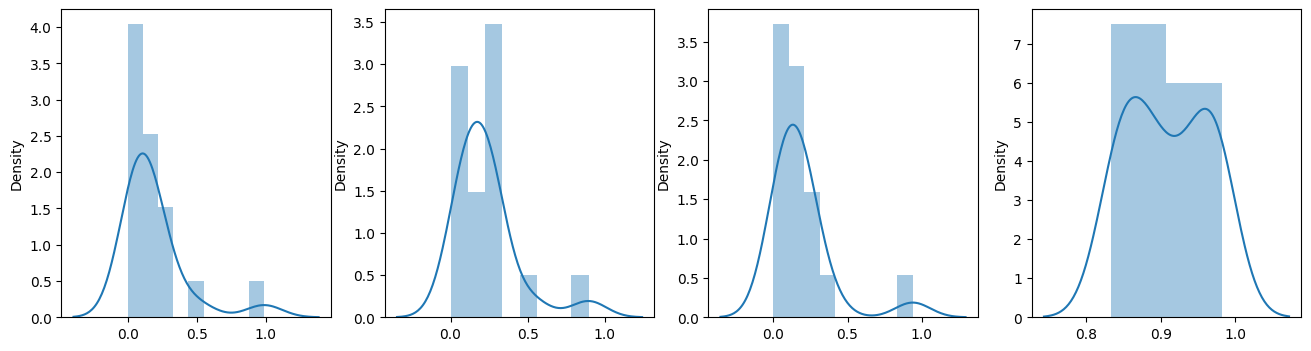

In [324]:
fig, axes = plt.subplots(1, 4, figsize=(16,4))
sns.distplot(rec_list[labeln>min_labeln], ax=axes[0]) 
sns.distplot(prec_list[labeln>min_labeln], ax=axes[1]) 
sns.distplot(f1_list[labeln>min_labeln], ax=axes[2]) 
sns.distplot(auc_list[labeln>min_labeln],ax=axes[3]) 

In [223]:
len(labels)

1109

In [222]:
len(labeln)


1109

In [210]:
all_pred_score.shape

torch.Size([34913, 1446])

In [208]:
pred_ids[:100]

tensor([ 170, 1375,  533,  741,  741,  741,  574,  292,  728,  741,  741,  999,
        1434,  728,  728,  728,  741,  466,  728,  728,  741, 1438,  728,  292,
         703,  437,  960,  466,  466,  605,  258,  628,  258,  607,  159, 1432,
         170, 1426, 1375, 1375, 1426, 1426,  159,  159,  707,  707,  159,  109,
         130,  556,  575,  592,  728, 1405,  437,  437,  437,  476,  722,  989,
         989, 1001, 1374, 1431, 1432, 1432, 1438,  170,  592,  592,  582,  960,
         258,  574,  159,  971, 1432,  437,  707, 1385,  962,  170,  437,  437,
         442, 1428, 1438,  466,  447,  466,  469,  469, 1438, 1438, 1438, 1438,
        1441,  466,  469, 1441], device='cuda:3')

In [209]:
labels[:100]

tensor([ 962,  365,  728,  728,  741,  987,  287,  723,  728,  741,  979, 1405,
         723,  728,  722,  741,  143,  697,  703,  741, 1437,  721,  741,  623,
         741,  437,  451,  465,  596,  715,  350,  712,  606,  606, 1183, 1438,
        1375, 1426,  601,  605, 1014, 1434,  606,  701,  707,  971,   99,   99,
         533,  574,  581,  722, 1010,  365,  380,  407,  473,  717,  789,  961,
         999, 1018, 1372, 1431, 1432, 1436, 1442,  575,  583,  592,  437,  533,
         575,  583,  963,  999, 1001,  707,  707,  601,  605,  818,  258,  437,
         466,  790, 1433,  443,  447,  466,  468,  469, 1428, 1432, 1432, 1438,
         447,  468,  588, 1438], device='cuda:3')

## Qwen3 eval

In [274]:
import torch
import os
import shutil
from torch.utils.data import DataLoader, Dataset
from accelerate import Accelerator
from transformers import Qwen3Config, Qwen3ForCausalLM, get_scheduler
import torch.optim as optim
from event_tokenizer import tokenizer, tokenizer_encode, vocab_size
from datetime import datetime
device = 'cuda:3'
model = Qwen3ForCausalLM.from_pretrained('icd10_tokenizer_base/qwen-icd10/best_model').to(device)
# model = Qwen3ForCausalLM.from_pretrained('icd10_tokenizer_posid/qwen-icd10-complete/best_model').to(device)
# model = Qwen3ForCausalLM.from_pretrained('icd10_tokenizer_posid/best_model').to(device)

In [275]:
model.config.max_position_embeddings

200

In [276]:
# from event_complete_tokenizer import tokenizer, tokenizer_encode, tokenizer_decode, vocab_size
from event_tokenizer import tokenizer, tokenizer_encode, tokenizer_decode, vocab_size


In [277]:
batch_size = 64
class ICDDataset(Dataset):
    def __init__(self, file_path):
        with open(file_path, 'r') as f:
            self.lines = [line.strip() for line in f.readlines()]
        self.max_len = 200

    def __len__(self):
        return len(self.lines)

    def __getitem__(self, idx):
        # Assuming tokenizer_encode is available globally or imported
        input_ids, seq_posids = tokenizer_encode(self.lines[idx])
        
        # Create tensors
        input_ids = torch.LongTensor(input_ids)
        seq_posids = torch.LongTensor(seq_posids)
        attn_mask = torch.ones_like(input_ids)
        
        # Padding logic
        pad_len = self.max_len - len(input_ids)
        if pad_len > 0:
            input_ids = torch.cat([input_ids, torch.zeros(pad_len, dtype=torch.long)])
            seq_posids = torch.cat([seq_posids, torch.zeros(pad_len, dtype=torch.long)])
            attn_mask = torch.cat([attn_mask, torch.zeros(pad_len, dtype=torch.long)])
        else:
            # Safety truncation if line is longer than max_len
            input_ids = input_ids[:self.max_len]
            seq_posids = seq_posids[:self.max_len]
            attn_mask = attn_mask[:self.max_len]

        return {
            "input_ids": input_ids,
            "seq_posids": seq_posids,
            "attention_mask": attn_mask,
        }

val_dataset = ICDDataset('icd10_val_split.txt')
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [278]:
from tqdm import tqdm

model.eval()

# Store predictions for metrics
all_gt = []   # 1 if prediction matches target, 0 otherwise
all_pred_score = []   # The probability score of the predicted token
all_pred_id = []   
all_seq_posid = []
all_input_id = []

print(f"Evaluating on {len(val_dataset)} sequences...")
print("-" * 50)

with torch.no_grad():
    for batch in tqdm(val_dataloader):
        seq_posids = batch["seq_posids"].to(device)
        input_ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        
        labels = input_ids[:, 2:]
        outputs = model(
                    input_ids=input_ids, 
                    labels=input_ids, 
                    attention_mask=mask, 
                    # position_ids=seq_posids
                )
        
        logits = outputs["logits"][:, 1:-1] # (1, seq_len, vocab)
        _, pred_ids = F.softmax(logits, dim=-1).max(-1)

        seq_mask = labels>3
        seq_posid = seq_posids[:, 2:][seq_mask]
        input_id = input_ids[:, 1:-1][seq_mask]
        logits = logits[seq_mask]
        pred_ids = pred_ids[seq_mask]
        labels = labels[seq_mask]        
        all_seq_posid.append(seq_posid.detach().cpu())
        all_input_id.append(input_id.detach().cpu())
        all_gt.append(labels.detach().cpu())
        all_pred_score.append(logits.detach().cpu())
        all_pred_id.append(pred_ids.detach().cpu())
all_gt = torch.cat(all_gt)
all_input_id = torch.cat(all_input_id)
all_pred_score = torch.cat(all_pred_score)
all_pred_id = torch.cat(all_pred_id)
all_seq_posid = torch.cat(all_seq_posid)


Evaluating on 3425 sequences...
--------------------------------------------------


100%|███████████████████████████████████████████| 54/54 [00:37<00:00,  1.45it/s]


In [279]:
import warnings
warnings.filterwarnings("ignore")

In [280]:
from sklearn import metrics
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from tqdm import tqdm
all_gt = all_gt.cpu()
all_pred_score = all_pred_score.cpu()
all_pred_id = all_pred_id.cpu()
labeln = []
labels = all_gt.unique().tolist()
auc_list = []
prec_list = []
rec_list = []
f1_list = []
pred_idx = all_pred_score.argmax(-1)
for labeli in tqdm(all_gt.unique()):
    gt = (all_gt == labeli).float()
    if gt.sum() < 2: continue
    pred_score = all_pred_score[:, labeli]
    pred = (pred_idx==labeli).float()
    auc = metrics.roc_auc_score(gt, pred_score)
    prec = precision_score(gt, pred)
    rec = recall_score(gt, pred)
    f1 = f1_score(gt, pred)
    prec_list.append(prec)
    rec_list.append(rec)
    f1_list.append(f1)
    auc_list.append(auc)
    labeln.append(gt.sum())
    # break
# auc, tokenizer_decode(all_gt.unique().tolist())[labeli]

100%|███████████████████████████████████████| 1110/1110 [01:11<00:00, 15.60it/s]


In [281]:
labeln = np.array(labeln)
auc_list = np.array(auc_list)
prec_list = np.array(prec_list)
rec_list = np.array(rec_list)
f1_list = np.array(f1_list)

In [282]:
labeln.max()

np.float32(190187.0)

In [283]:
min_labeln = 300
sum(labeln>min_labeln)

np.int64(18)

In [183]:
np.mean(rec_list[labeln>min_labeln]), np.mean(prec_list[labeln>min_labeln]), np.mean(f1_list[labeln>min_labeln]), np.mean(auc_list[labeln>min_labeln]), np.std(rec_list[labeln>min_labeln]), np.std(prec_list[labeln>min_labeln]), np.std(f1_list[labeln>min_labeln]), np.std(auc_list[labeln>min_labeln])

(np.float64(0.23141725454834314),
 np.float64(0.26667104575399425),
 np.float64(0.23063387317055195),
 np.float64(0.9170528746309645),
 np.float64(0.2293909372411134),
 np.float64(0.18096281053008034),
 np.float64(0.20395103471687742),
 np.float64(0.048601989450965645))

In [284]:
np.mean(rec_list[labeln>min_labeln]), np.mean(prec_list[labeln>min_labeln]), np.mean(f1_list[labeln>min_labeln]), np.mean(auc_list[labeln>min_labeln]), np.std(rec_list[labeln>min_labeln]), np.std(prec_list[labeln>min_labeln]), np.std(f1_list[labeln>min_labeln]), np.std(auc_list[labeln>min_labeln])

(np.float64(0.19221947901740918),
 np.float64(0.20284324584251123),
 np.float64(0.18170297337150174),
 np.float64(0.8931227330416383),
 np.float64(0.22940207879521282),
 np.float64(0.19069935517045666),
 np.float64(0.20674419061654964),
 np.float64(0.05483819195223457))

In [358]:
(rec_list[labeln>min_labeln]), (prec_list[labeln>min_labeln]), (f1_list[labeln>min_labeln]), (auc_list[labeln>min_labeln])

(array([0.99312782, 0.24534161, 0.04911591, 0.327051  , 0.51674641,
        0.01960784, 0.04186047, 0.3131524 , 0.19946092, 0.05498282,
        0.        , 0.11548556, 0.00481928, 0.14577259, 0.05510907,
        0.15448852, 0.01006036, 0.12593985]),
 array([0.89686184, 0.24610592, 0.10330579, 0.1406101 , 0.27067669,
        0.07608696, 0.05882353, 0.2016129 , 0.22289157, 0.1871345 ,
        0.        , 0.11859838, 0.02857143, 0.23923445, 0.12903226,
        0.42285714, 0.2       , 0.25      ]),
 array([0.94254319, 0.24572317, 0.0665779 , 0.19666667, 0.35526316,
        0.0311804 , 0.04891304, 0.24529845, 0.21052632, 0.08499336,
        0.        , 0.11702128, 0.00824742, 0.18115942, 0.0772325 ,
        0.22629969, 0.01915709, 0.1675    ]),
 array([0.92797284, 0.85528944, 0.81106084, 0.87227472, 0.94348225,
        0.75501696, 0.78394723, 0.85864994, 0.91331681, 0.85002174,
        0.82522124, 0.83443382, 0.792531  , 0.95455996, 0.94476146,
        0.95460718, 0.93378852, 0.96229356]))

<Axes: ylabel='Density'>

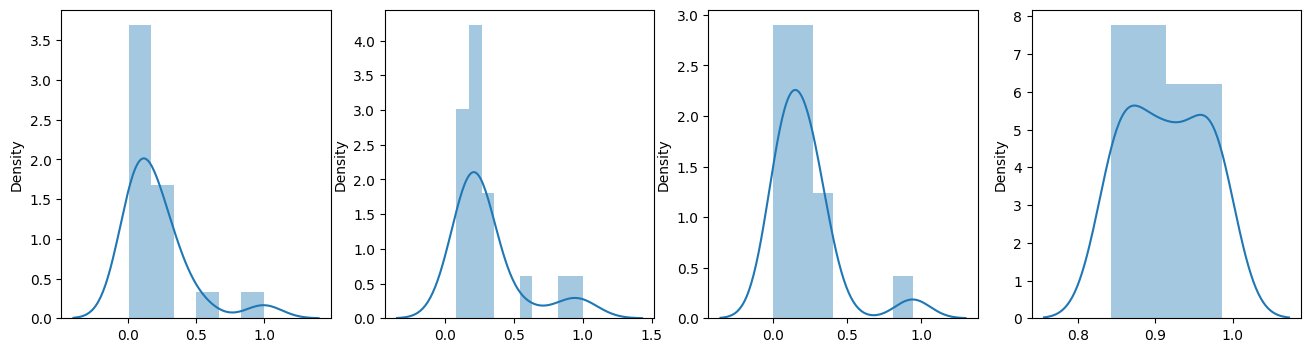

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 4, figsize=(16,4))
sns.distplot(rec_list[labeln>min_labeln], ax=axes[0]) 
sns.distplot(prec_list[labeln>min_labeln], ax=axes[1]) 
sns.distplot(f1_list[labeln>min_labeln], ax=axes[2]) 
sns.distplot(auc_list[labeln>min_labeln],ax=axes[3]) 

## Qwen3 distance vs AUC

In [314]:
vocab_id2str = {v: k for k, v in tokenizer.items()}
labels = all_gt.unique().tolist()


In [315]:
all_gt[all_gt!=tokenizer['CN']].shape

torch.Size([34913])

In [316]:
all_prev_id = []
mask = []
for j, i in tqdm(enumerate(torch.where(all_gt!=tokenizer['CN'])[0])):
    input_id = all_input_id[i]
    seq_posid = all_seq_posid[i]
    if input_id != tokenizer['CN']:
        all_prev_id.append(input_id.item())
        mask.append(j)
    elif i > 0:
        ii = i
        while all_input_id[ii] == tokenizer['CN'] and all_seq_posid[ii-1] <= all_seq_posid[ii]:
            ii -= 1
        if all_input_id[ii] != tokenizer['CN']:
            all_prev_id.append(all_input_id[ii].item())
            mask.append(j)

34913it [00:55, 623.61it/s] 


In [317]:
all_prev_id[:10], all_input_id[all_gt!=tokenizer['CN']][:10]

([1106, 1301, 462, 170, 701, 707, 390, 1433, 292, 339],
 tensor([ 148, 1106,  148,  148,  170,  701,  148,  390,  148,  292]))

In [318]:
p_all_gt = all_gt[all_gt!=tokenizer['CN']][mask]
p_all_pred_score = all_pred_score[all_gt!=tokenizer['CN']][mask]
all_prev_id = torch.tensor(all_prev_id)


In [319]:
all_prev_id.unique().shape

torch.Size([1091])

In [320]:
from sklearn import metrics
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from tqdm import tqdm
gt_dist_group_dict = {}
pred_dist_group_dict = {}
predscore_dist_group_dict = {}
pred_idx = p_all_pred_score.argmax(-1)
for labeli in tqdm(p_all_gt.unique()):
    gt = (p_all_gt == labeli).float()
    if gt.sum() < 2: continue
    gt_icd = vocab_id2str[labeli.item()]
    for previ in all_prev_id.unique():
        mask = all_prev_id==previ
        if gt[mask.cpu()].sum() < 2: continue
        prev_icd = vocab_id2str[previ.item()]
        icdkey = f'{gt_icd}-{prev_icd}'
        assert 'CN' not in icdkey, icdkey
        # icdkey = f'{prev_icd}'
        if icdkey not in gt_dist_group_dict: 
            gt_dist_group_dict[icdkey] = []
            pred_dist_group_dict[icdkey] = []
            predscore_dist_group_dict[icdkey] = []
        
        cur_pred_score = p_all_pred_score[:, labeli]
        pred = (pred_idx==labeli).float()
        predscore_dist_group_dict[icdkey].append(cur_pred_score[mask.cpu()])
        pred_dist_group_dict[icdkey].append(pred[mask.cpu()])
        gt_dist_group_dict[icdkey].append(gt[mask.cpu()])


100%|███████████████████████████████████████| 1084/1084 [01:01<00:00, 17.67it/s]


In [321]:
gt_dist_group_dict = {k: torch.cat(v) for k, v in gt_dist_group_dict.items()}
pred_dist_group_dict = {k: torch.cat(v) for k, v in pred_dist_group_dict.items()}
predscore_dist_group_dict = {k: torch.cat(v) for k, v in predscore_dist_group_dict.items()}


In [322]:
len(pred_dist_group_dict)

4371

In [323]:
np.bincount([len(pred_dist_group_dict[k]) for k in pred_dist_group_dict])[:100]

array([ 0,  0,  7,  9, 14, 14, 15, 19, 26, 18, 15, 16, 24, 16, 10, 22, 22,
       27, 18, 18, 22, 13, 35, 28, 27, 11, 27,  7, 12,  3, 24, 50, 17, 20,
       24, 31,  4, 23, 33, 11, 34, 16,  6, 11, 25, 27, 25, 13, 45, 11,  8,
       18, 25, 19, 19,  0,  9, 38,  8, 20, 26,  8,  0, 10, 17,  0,  7,  6,
       12, 13, 14,  0, 13, 13, 53,  0,  0, 11,  0,  0, 11, 28, 34, 16, 19,
       16, 18, 29,  0, 10, 56, 23, 29, 11, 37, 13,  0,  0,  0,  0])

In [296]:
import pandas as pd

icd2ch_str = '''
Chapter I Certain infectious and parasitic diseases-
A00-A09 Intestinal infectious diseases32122
A15-A19 Tuberculosis463
A20-A28 Certain zoonotic bacterial diseases85
A30-A49 Other bacterial diseases24828
A50-A64 Infections with a predominantly sexual mode of transmission358
A65-A69 Other spirochaetal diseases158
A70-A74 Other diseases caused by chlamydiae14
A75-A79 Rickettsioses16
A80-A89 Viral infections of the central nervous system510
A92-A99 Arthropod-borne viral fevers and viral haemorrhagic fevers6
B00-B09 Viral infections characterized by skin and mucous membrane lesions4187
B15-B19 Viral hepatitis1659
B20-B24 Human immunodeficiency virus [HIV] disease310
B25-B34 Other viral diseases4374
B35-B49 Mycoses10524
B50-B64 Protozoal diseases523
B65-B83 Helminthiases302
B85-B89 Pediculosis, acariasis and other infestations118
B90-B94 Sequelae of infectious and parasitic diseases521
B95-B98 Bacterial, viral and other infectious agents45541
B99-B99 Other infectious diseases956
Chapter II Neoplasms-
C00-C14 Malignant neoplasms of lip, oral cavity and pharynx2854
C15-C26 Malignant neoplasms of digestive organs26369
C30-C39 Malignant neoplasms of respiratory and intrathoracic organs10486
C40-C41 Malignant neoplasms of bone and articular cartilage315
C43-C44 Melanoma and other malignant neoplasms of skin41388
C45-C49 Malignant neoplasms of mesothelial and soft tissue2273
C50-C50 Malignant neoplasm of breast23908
C51-C58 Malignant neoplasms of female genital organs6387
C60-C63 Malignant neoplasms of male genital organs16702
C64-C68 Malignant neoplasms of urinary tract10122
C69-C72 Malignant neoplasms of eye, brain and other parts of central nervous system2364
C73-C75 Malignant neoplasms of thyroid and other endocrine glands1006
C76-C80 Malignant neoplasms of ill-defined, secondary and unspecified sites60880
C81-C96 Malignant neoplasms, stated or presumed to be primary, of lymphoid, haematopoietic and related tissue13786
C97-C97 Malignant neoplasms of independent (primary) multiple sites2011
D00-D09 In situ neoplasms11665
D10-D36 Benign neoplasms124444
D37-D48 Neoplasms of uncertain or unknown behaviour13071
Chapter III Diseases of the blood and blood-forming organs and certain disorders involving the immune mechanism-
D50-D53 Nutritional anaemias33143
D55-D59 Haemolytic anaemias2147
D60-D64 Aplastic and other anaemias37584
D65-D69 Coagulation defects, purpura and other haemorrhagic conditions9331
D70-D77 Other diseases of blood and blood-forming organs12770
D80-D89 Certain disorders involving the immune mechanism3593
Chapter IV Endocrine, nutritional and metabolic diseases-
E00-E07 Disorders of thyroid gland44663
E10-E14 Diabetes mellitus69720
E15-E16 Other disorders of glucose regulation and pancreatic internal secretion4344
E20-E35 Disorders of other endocrine glands9734
E40-E46 Malnutrition753
E50-E64 Other nutritional deficiencies13791
E65-E68 Obesity and other hyperalimentation45891
E70-E90 Metabolic disorders173831
Chapter V Mental and behavioural disorders-
F00-F09 Organic, including symptomatic, mental disorders26178
F10-F19 Mental and behavioural disorders due to psychoactive substance use46052
F20-F29 Schizophrenia, schizotypal and delusional disorders3673
F30-F39 Mood [affective] disorders41336
F40-F48 Neurotic, stress-related and somatoform disorders36945
F50-F59 Behavioural syndromes associated with physiological disturbances and physical factors1488
F60-F69 Disorders of adult personality and behaviour1182
F70-F79 Mental retardation275
F80-F89 Disorders of psychological development1094
F90-F98 Behavioural and emotional disorders with onset usually occurring in childhood and adolescence182
F99-F99 Unspecified mental disorder409
Chapter VI Diseases of the nervous system-
G00-G09 Inflammatory diseases of the central nervous system1738
G10-G14 Systemic atrophies primarily affecting the central nervous system1304
G20-G26 Extrapyramidal and movement disorders9213
G30-G32 Other degenerative diseases of the nervous system8964
G35-G37 Demyelinating diseases of the central nervous system2757
G40-G47 Episodic and paroxysmal disorders41063
G50-G59 Nerve, nerve root and plexus disorders39734
G60-G64 Polyneuropathies and other disorders of the peripheral nervous system8162
G70-G73 Diseases of myoneural junction and muscle1457
G80-G83 Cerebral palsy and other paralytic syndromes7622
G90-G99 Other disorders of the nervous system13970
Chapter VII Diseases of the eye and adnexa-
H00-H06 Disorders of eyelid, lacrimal system and orbit26370
H10-H13 Disorders of conjunctiva3049
H15-H22 Disorders of sclera, cornea, iris and ciliary body10343
H25-H28 Disorders of lens102533
H30-H36 Disorders of choroid and retina33032
H40-H42 Glaucoma21907
H43-H45 Disorders of vitreous body and globe6343
H46-H48 Disorders of optic nerve and visual pathways1479
H49-H52 Disorders of ocular muscles, binocular movement, accommodation and refraction19884
H53-H54 Visual disturbances and blindness14147
H55-H59 Other disorders of eye and adnexa3511
Chapter VIII Diseases of the ear and mastoid process-
H60-H62 Diseases of external ear3288
H65-H75 Diseases of middle ear and mastoid7677
H80-H83 Diseases of inner ear6185
H90-H95 Other disorders of ear23076
Chapter IX Diseases of the circulatory system-
I00-I02 Acute rheumatic fever75
I05-I09 Chronic rheumatic heart diseases14442
I10-I15 Hypertensive diseases169852
I20-I25 Ischaemic heart diseases173720
I26-I28 Pulmonary heart disease and diseases of pulmonary circulation14792
I30-I52 Other forms of heart disease201019
I60-I69 Cerebrovascular diseases43101
I70-I79 Diseases of arteries, arterioles and capillaries32762
I80-I89 Diseases of veins, lymphatic vessels and lymph nodes, not elsewhere classified77144
I95-I99 Other and unspecified disorders of the circulatory system26080
Chapter X Diseases of the respiratory system-
J00-J06 Acute upper respiratory infections6419
J09-J18 Influenza and pneumonia46314
J20-J22 Other acute lower respiratory infections20575
J30-J39 Other diseases of upper respiratory tract40240
J40-J47 Chronic lower respiratory diseases103772
J60-J70 Lung diseases due to external agents5591
J80-J84 Other respiratory diseases principally affecting the interstitium7410
J85-J86 Suppurative and necrotic conditions of lower respiratory tract1119
J90-J94 Other diseases of pleura27058
J95-J99 Other diseases of the respiratory system30938
Chapter XI Diseases of the digestive system-
K00-K14 Diseases of oral cavity, salivary glands and jaws38508
K20-K31 Diseases of oesophagus, stomach and duodenum254835
K35-K38 Diseases of appendix6812
K40-K46 Hernia107039
K50-K52 Noninfective enteritis and colitis41224
K55-K64 Other diseases of intestines287541
K65-K67 Diseases of peritoneum12376
K70-K77 Diseases of liver27238
K80-K87 Disorders of gallbladder, biliary tract and pancreas67373
K90-K93 Other diseases of the digestive system36615
Chapter XII Diseases of the skin and subcutaneous tissue-
L00-L08 Infections of the skin and subcutaneous tissue28299
L10-L14 Bullous disorders582
L20-L30 Dermatitis and eczema12156
L40-L45 Papulosquamous disorders8827
L50-L54 Urticaria and erythema3020
L55-L59 Radiation-related disorders of the skin and subcutaneous tissue7725
L60-L75 Disorders of skin appendages18178
L80-L99 Other disorders of the skin and subcutaneous tissue47367
Chapter XIII Diseases of the musculoskeletal system and connective tissue-
M00-M03 Infectious arthropathies1274
M05-M14 Inflammatory polyarthropathies80611
M15-M19 Arthrosis160920
M20-M25 Other joint disorders99996
M30-M36 Systemic connective tissue disorders11237
M40-M43 Deforming dorsopathies12316
M45-M49 Spondylopathies54718
M50-M54 Other dorsopathies79889
M60-M63 Disorders of muscles3477
M65-M68 Disorders of synovium and tendon18630
M70-M79 Other soft tissue disorders84367
M80-M85 Disorders of bone density and structure42179
M86-M90 Other osteopathies8458
M91-M94 Chondropathies2556
M95-M99 Other disorders of the musculoskeletal system and connective tissue2504
Chapter XIV Diseases of the genitourinary system-
N00-N08 Glomerular diseases5176
N10-N16 Renal tubulo-interstitial diseases14492
N17-N19 Renal failure67111
N20-N23 Urolithiasis17024
N25-N29 Other disorders of kidney and ureter10711
N30-N39 Other diseases of urinary system86904
N40-N51 Diseases of male genital organs55641
N60-N64 Disorders of breast9917
N70-N77 Inflammatory diseases of female pelvic organs10640
N80-N98 Noninflammatory disorders of female genital tract131802
N99-N99 Other disorders of the genitourinary system2063
Chapter XV Pregnancy, childbirth and the puerperium-
O00-O08 Pregnancy with abortive outcome5651
O10-O16 Oedema, proteinuria and hypertensive disorders in pregnancy, childbirth and the puerperium2140
O20-O29 Other maternal disorders predominantly related to pregnancy4963
O30-O48 Maternal care related to the fetus and amniotic cavity and possible delivery problems13390
O60-O75 Complications of labour and delivery21421
O80-O84 Delivery3681
O85-O92 Complications predominantly related to the puerperium883
O94-O99 Other obstetric conditions, not elsewhere classified2637
Chapter XVI Certain conditions originating in the perinatal period-
P00-P04 Fetus and newborn affected by maternal factors and by complications of pregnancy, labour and delivery3
P05-P08 Disorders related to length of gestation and fetal growth5
P10-P15 Birth trauma23
P20-P29 Respiratory and cardiovascular disorders specific to the perinatal period7
P35-P39 Infections specific to the perinatal period6
P50-P61 Haemorrhagic and haematological disorders of fetus and newborn1
P80-P83 Conditions involving the integument and temperature regulation of fetus and newborn4
P90-P96 Other disorders originating in the perinatal period3
Chapter XVII Congenital malformations, deformations and chromosomal abnormalities-
Q00-Q07 Congenital malformations of the nervous system641
Q10-Q18 Congenital malformations of eye, ear, face and neck761
Q20-Q28 Congenital malformations of the circulatory system3331
Q30-Q34 Congenital malformations of the respiratory system172
Q35-Q37 Cleft lip and cleft palate63
Q38-Q45 Other congenital malformations of the digestive system1842
Q50-Q56 Congenital malformations of genital organs1220
Q60-Q64 Congenital malformations of the urinary system2192
Q65-Q79 Congenital malformations and deformations of the musculoskeletal system1925
Q80-Q89 Other congenital malformations1296
Q90-Q99 Chromosomal abnormalities, not elsewhere classified264
Chapter XVIII Symptoms, signs and abnormal clinical and laboratory findings, not elsewhere classified-
R00-R09 Symptoms and signs involving the circulatory and respiratory systems156207
R10-R19 Symptoms and signs involving the digestive system and abdomen180403
R20-R23 Symptoms and signs involving the skin and subcutaneous tissue18475
R25-R29 Symptoms and signs involving the nervous and musculoskeletal systems43232
R30-R39 Symptoms and signs involving the urinary system77771
R40-R46 Symptoms and signs involving cognition, perception, emotional state and behaviour39963
R47-R49 Symptoms and signs involving speech and voice8326
R50-R69 General symptoms and signs155019
R70-R79 Abnormal findings on examination of blood, without diagnosis28397
R80-R82 Abnormal findings on examination of urine, without diagnosis1885
R83-R89 Abnormal findings on examination of other body fluids, substances and tissues, without diagnosis3300
R90-R94 Abnormal findings on diagnostic imaging and in function studies, without diagnosis33418
R95-R99 Ill-defined and unknown causes of mortality11
Chapter XIX Injury, poisoning and certain other consequences of external causes-
S00-S09 Injuries to the head36393
S10-S19 Injuries to the neck2462
S20-S29 Injuries to the thorax10869
S30-S39 Injuries to the abdomen, lower back, lumbar spine and pelvis10031
S40-S49 Injuries to the shoulder and upper arm10327
S50-S59 Injuries to the elbow and forearm17269
S60-S69 Injuries to the wrist and hand19427
S70-S79 Injuries to the hip and thigh11148
S80-S89 Injuries to the knee and lower leg19164
S90-S99 Injuries to the ankle and foot4655
T00-T07 Injuries involving multiple body regions1141
T08-T14 Injuries to unspecified part of trunk, limb or body region1110
T15-T19 Effects of foreign body entering through natural orifice2159
T20-T25 Burns and corrosions of external body surface, specified by site1451
T26-T28 Burns and corrosions confined to eye and internal organs71
T29-T32 Burns and corrosions of multiple and unspecified body regions735
T33-T35 Frostbite11
T36-T50 Poisoning by drugs, medicaments and biological substances11805
T51-T65 Toxic effects of substances chiefly nonmedicinal as to source2267
T66-T78 Other and unspecified effects of external causes2953
T79-T79 Certain early complications of trauma1176
T80-T88 Complications of surgical and medical care, not elsewhere classified66450
T90-T98 Sequelae of injuries, of poisoning and of other consequences of external causes5005
Chapter XX External causes of morbidity and mortality-
V01-V09 Pedestrian injured in transport accident1270
V10-V19 Pedal cyclist injured in transport accident3961
V20-V29 Motorcycle rider injured in transport accident1366
V30-V39 Occupant of three-wheeled motor vehicle injured in transport accident22
V40-V49 Car occupant injured in transport accident2448
V50-V59 Occupant of pick-up truck or van injured in transport accident84
V60-V69 Occupant of heavy transport vehicle injured in transport accident87
V70-V79 Bus occupant injured in transport accident357
V80-V89 Other land transport accidents974
V90-V94 Water transport accidents158
V95-V97 Air and space transport accidents90
V98-V99 Other and unspecified transport accidents47
W00-W19 Falls61521
W20-W49 Exposure to inanimate mechanical forces11180
W50-W64 Exposure to animate mechanical forces3733
W65-W74 Accidental drowning and submersion38
W75-W84 Other accidental threats to breathing1108
W85-W99 Exposure to electric current, radiation and extreme ambient air temperature and pressure159
X00-X09 Exposure to smoke, fire and flames260
X10-X19 Contact with heat and hot substances519
X20-X29 Contact with venomous animals and plants330
X30-X39 Exposure to forces of nature178
X40-X49 Accidental poisoning by and exposure to noxious substances2993
X50-X57 Overexertion, travel and privation2435
X58-X59 Accidental exposure to other and unspecified factors8080
X60-X84 Intentional self-harm9068
X85-X99 Assault297
Y00-Y09 Assault1583
Y10-Y34 Event of undetermined intent251
Y35-Y36 Legal intervention and operations of war5
Y40-Y59 Drugs, medicaments and biological substances causing adverse effects in therapeutic use23657
Y60-Y69 Misadventures to patients during surgical and medical care2801
Y70-Y82 Medical devices associated with adverse incidents in diagnostic and therapeutic use890
Y83-Y84 Surgical and other medical procedures as the cause of abnormal reaction of the patient, or of later complication, without mention of misadventure at the time of the procedure51338
Y85-Y89 Sequelae of external causes of morbidity and mortality3062
Y90-Y98 Supplementary factors related to causes of morbidity and mortality classified elsewhere8415
Chapter XXI Factors influencing health status and contact with health services-
Z00-Z13 Persons encountering health services for examination and investigation139593
Z20-Z29 Persons with potential health hazards related to communicable diseases9347
Z30-Z39 Persons encountering health services in circumstances related to reproduction33426
Z40-Z54 Persons encountering health services for specific procedures and health care218061
Z55-Z65 Persons with potential health hazards related to socioeconomic and psychosocial circumstances12867
Z70-Z76 Persons encountering health services in other circumstances49039
Z80-Z99 Persons with potential health hazards related to family and personal history and certain conditions influencing health status870585
Chapter XXII Codes for special purposes-
U00-U49 Provisional assignment of new diseases of uncertain etiology or emergency use19180
U82-U85 Resistance to antimicrobial and antineoplastic drugs
'''
coding = pd.read_csv('../data/meta_data/ukb_phenotype_info/data_coding/coding_000019.tsv', sep='\t')
pdata = coding[coding['coding'].map(lambda x: len(x)==3)]
icd2ch = {}
for line in icd2ch_str.split('\n')[1:-1]:
    if line.startswith('Ch'):
        cur_v = line.split(' ')[1]
    else:
        startend = line.split(' ')[0]
        s, e = startend.split('-')
        assert s[0] == e[0], f'{s}, {e}'
        for i in range(int(s[1:]), int(e[1:])+1):
            icd2ch[f'{s[0]}{i:02d}'] = cur_v

icd = [icd2ch[x[:3]] if x[:3] in icd2ch else None for x in pdata['meaning'].tolist() ]

In [297]:
distance_dict = torch.laoad('../StableDiffusion-PyTorch/icd2icd_meaning_distance.pth')
distance = distance_dict['distance']
distance_ticks = distance_dict['ticks']

In [299]:
qwen3_final_res = torch.load('pretrain_result_Qwen3-complete.pt')
our_gt_dist_group_dict = qwen3_final_res['gt']
our_pred_dist_group_dict = qwen3_final_res['pred_id']
our_predscore_dist_group_dict = qwen3_final_res['pred_logits']

In [300]:
base_final_res = torch.load('pretrain_result_Qwen3-base.pt')
base_gt_dist_group_dict = base_final_res['gt']
base_pred_dist_group_dict = base_final_res['pred_id']
base_predscore_dist_group_dict = base_final_res['pred_logits']

In [325]:
delphi_res = torch.load('../StableDiffusion-PyTorch/pretrain_result_Delphi-base.pt')
delphi_base_gt_dist_group_dict = delphi_res["gt"]
delphi_base_pred_dist_group_dict = delphi_res["pred_id"]
delphi_base_predscore_dist_group_dict = delphi_res["pred_logits"]

In [298]:
# torch.save({"gt": gt_dist_group_dict, "pred_id": pred_dist_group_dict, "pred_logits": predscore_dist_group_dict}, 'pretrain_result_Qwen3-base.pt')

In [119]:
delphi_res = torch.load('../StableDiffusion-PyTorch/pretrain_result_Delphi.pt')
delphi_gt_dist_group_dict = delphi_res["gt"]
delphi_pred_dist_group_dict = delphi_res["pred_id"]
delphi_predscore_dist_group_dict = delphi_res["pred_logits"]

In [347]:
# auc_dist_group = torch.zeros_like(distance)
# f1_group = torch.zeros_like(distance)
# labeln_group = torch.zeros_like(distance)
group_vw = []
group_c = []
same_group = []
same_chapter = []
aucs = []
f1s = []
precs = []
recs = []
subjns = []
labelns = []
distance_list = []
methods = []
for k in tqdm(pred_dist_group_dict):
    icd1, icd2 = k.split('-')
    assert icd1 in icd2ch, icd1
    assert icd2 in icd2ch, icd2
    ch1 = icd2ch[icd1]# 
    ch2 = icd2ch[icd2]# 
    i, j = distance_ticks.index(icd1), distance_ticks.index(icd2)
    if k not in delphi_pred_dist_group_dict: continue
    if our_gt_dist_group_dict[k].sum() <= 2 or len(our_gt_dist_group_dict[k]) == our_gt_dist_group_dict[k].sum(): continue
    if delphi_gt_dist_group_dict[k].sum() <= 2 or len(delphi_gt_dist_group_dict[k]) == delphi_gt_dist_group_dict[k].sum(): continue
    
    
    
    pred = base_pred_dist_group_dict[k]
    pred_score = base_predscore_dist_group_dict[k]
    gt = base_gt_dist_group_dict[k]
    auc = metrics.roc_auc_score(gt, pred_score)
    prec = precision_score(gt, pred)
    rec = recall_score(gt, pred)
    f1 = f1_score(gt, pred)
    same_chapter.append(ch1 == ch2)
    same_group.append(icd1[0] == icd2[0])
    distance_list.append(distance[i, j])
    aucs.append(auc)
    precs.append(prec)
    recs.append(rec)
    f1s.append(f1)
    labelns.append(gt.sum())
    subjns.append(len(gt))
    group_vw.append('V' in k or 'W' in k)
    group_c.append('C' in k)
    methods.append('Delphi-Qwen3')

    
    pred = delphi_base_pred_dist_group_dict[k]
    pred_score = delphi_base_predscore_dist_group_dict[k]
    gt = delphi_base_gt_dist_group_dict[k]
    auc = metrics.roc_auc_score(gt, pred_score)
    prec = precision_score(gt, pred)
    rec = recall_score(gt, pred)
    f1 = f1_score(gt, pred)
    same_chapter.append(ch1 == ch2)
    same_group.append(icd1[0] == icd2[0])
    distance_list.append(distance[i, j])
    aucs.append(auc)
    precs.append(prec)
    recs.append(rec)
    f1s.append(f1)
    labelns.append(gt.sum())
    subjns.append(len(gt))
    group_vw.append('V' in k or 'W' in k)
    group_c.append('C' in k)
    methods.append('DiffDT-GPT2')
    
    
    pred = our_pred_dist_group_dict[k]
    pred_score = our_predscore_dist_group_dict[k]
    gt = our_gt_dist_group_dict[k]
    auc = metrics.roc_auc_score(gt, pred_score)
    prec = precision_score(gt, pred)
    rec = recall_score(gt, pred)
    f1 = f1_score(gt, pred)
    same_chapter.append(ch1 == ch2)
    same_group.append(icd1[0] == icd2[0])
    distance_list.append(distance[i, j])
    aucs.append(auc)
    precs.append(prec)
    recs.append(rec)
    f1s.append(f1)
    labelns.append(gt.sum())
    subjns.append(len(gt))
    group_vw.append('V' in k or 'W' in k)
    group_c.append('C' in k)
    methods.append('DiffDT-Qwen3')

    
    pred = delphi_pred_dist_group_dict[k]
    pred_score = delphi_predscore_dist_group_dict[k]
    gt = delphi_gt_dist_group_dict[k]
    auc = metrics.roc_auc_score(gt, pred_score)
    prec = precision_score(gt, pred)
    rec = recall_score(gt, pred)
    f1 = f1_score(gt, pred)
    same_chapter.append(ch1 == ch2)
    same_group.append(icd1[0] == icd2[0])
    distance_list.append(distance[i, j])
    aucs.append(auc)
    precs.append(prec)
    recs.append(rec)
    f1s.append(f1)
    labelns.append(gt.sum())
    subjns.append(len(gt))
    group_vw.append('V' in k or 'W' in k)
    group_c.append('C' in k)
    methods.append('Delphi-GPT2')
    

100%|██████████████████████████████████████| 4371/4371 [00:32<00:00, 135.11it/s]


In [348]:
len([1 for k in pred_dist_group_dict if k in delphi_pred_dist_group_dict]), len(pred_dist_group_dict)


(3132, 4371)

In [349]:
group_vw = np.array(group_vw)
group_c = np.array(group_c)
same_chapter = np.array(same_chapter)
same_group = np.array(same_group)
labelns = np.array(labelns)
subjns = np.array(subjns)
distance_list = np.array(distance_list)
aucs = np.array(aucs)
precs = np.array(precs)
recs = np.array(recs)
f1s = np.array(f1s)
methods = np.array(methods)

In [350]:
group_vw.sum()

np.int64(68)

In [587]:
def auc_one_plot(x, y, label_num, color, color2, alpha=0.3):
    # Calculate Pearson correlation
    r, p = stats.pearsonr(x, y)
    print(r, p)
    sns.regplot(x=x, y=y, scatter=False, line_kws={'color': color2, 'alpha': 0.7, 'linewidth': 4})
    scatter = plt.scatter(x, y, c=color, s=10, zorder=-1, alpha=alpha)
    # 3. Annotate Pearson's correlation with Arial font
    # plt.text(tx, ty, f"r = {r:.2f}\np = {p:.3f}", 
    #          transform=plt.gca().transAxes, 
    #          color='blue',
    #          fontsize=12, 
    #          fontname='Arial',
    #          verticalalignment='top')

-0.20098699135016604 0.04177804922310366
0.719427194656999
-0.04507374058279281 0.6512001197658354
0.6375332453018332
-0.17926656844083214 0.07000773770947227
0.6226624938890449
0.07112632556270529 0.6163242924203344
0.6372969456534364


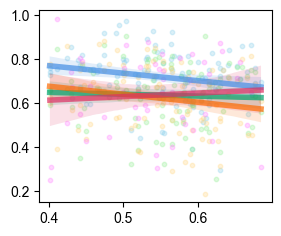

In [627]:

import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
# Set global font to Arial
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
# Synthetic data
# mask = (labelns>10) & (distance_list>0) & (distance_list<0.5)  & same_chapter
# mask = (labelns>1) & (distance_list>0) &  same_chapter
p_mask = ((labelns/subjns)>0.1)  & (distance_list>0.4) & (distance_list<0.6) &  ~same_chapter
# p_mask = ((labelns/subjns)>0.05) & (distance_list>0.4) &  ~same_chapter
p_mask = ((labelns/subjns)>0.07) &(distance_list>0.4) & (distance_list<0.7) &  ~same_chapter

# p_mask = ((labelns/subjns)>0.) & (distance_list>0) & (group_vw|group_c)

plt.figure(figsize=(3, 2.5))
mask = p_mask & (methods == 'DiffDT-Qwen3')
auc_one_plot(distance_list[mask], aucs[mask], labelns[mask], 'skyblue', '#448ee4')
print(np.mean(aucs[mask]))
mask = p_mask & (methods == 'DiffDT-GPT2')
auc_one_plot(distance_list[mask], aucs[mask], labelns[mask], 'lightgreen', '#00A36C')
print(np.mean(aucs[mask]))
mask = p_mask & (methods == 'Delphi-Qwen3')
auc_one_plot(distance_list[mask], aucs[mask], labelns[mask], '#FFD580', '#FC6A03') # magenta
print(np.mean(aucs[mask]))
mask = p_mask & (methods == 'Delphi-GPT2')
auc_one_plot(distance_list[mask], aucs[mask], labelns[mask], '#FF80FF', '#DE3163') # orange
print(np.mean(aucs[mask]))
plt.savefig('../StableDiffusion-PyTorch/icml26_fig_exp1_off-diag.svg')

-0.3830035911231271 0.0012656892736969572
0.2908767598835494
-0.3881581916950956 0.0010726221450098302
0.2355463456422088
-0.3524039324097853 0.003205623413222005
0.2504056799908748
-0.18519376215636826 0.2795479623672172
0.22807075844882194


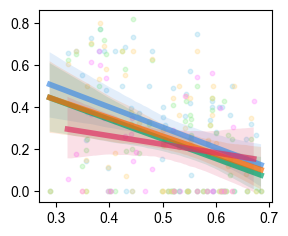

In [645]:

import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
# Set global font to Arial
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
# Synthetic data
# mask = (labelns>10) & (distance_list>0) & (distance_list<0.5)  & same_chapter
# mask = (labelns>1) & (distance_list>0) &  same_chapter
p_mask = ((labelns/subjns)>0.1)  & (distance_list>0.4) & (distance_list<0.6) &  ~same_chapter
# p_mask = ((labelns/subjns)>0.05) & (distance_list>0.4) &  ~same_chapter
p_mask = ((labelns/subjns)>0.1) &(distance_list>0.) & (distance_list<0.7) &  ~same_chapter #& (f1s>0)

# p_mask = ((labelns/subjns)>0.) & (distance_list>0) & (group_vw|group_c)

plt.figure(figsize=(3, 2.5))
mask = p_mask & (methods == 'DiffDT-Qwen3')
auc_one_plot(distance_list[mask], f1s[mask], labelns[mask], 'skyblue', '#448ee4')
print(np.mean(f1s[mask]))
mask = p_mask & (methods == 'DiffDT-GPT2')
auc_one_plot(distance_list[mask], f1s[mask], labelns[mask], 'lightgreen', '#00A36C')
print(np.mean(f1s[mask]))
mask = p_mask & (methods == 'Delphi-Qwen3')
auc_one_plot(distance_list[mask], f1s[mask], labelns[mask], '#FFD580', '#FC6A03') # magenta
print(np.mean(f1s[mask]))
mask = p_mask & (methods == 'Delphi-GPT2')
auc_one_plot(distance_list[mask], f1s[mask], labelns[mask], '#FF80FF', '#DE3163') # orange
print(np.mean(f1s[mask]))
plt.savefig('../StableDiffusion-PyTorch/icml26_fig_exp1_f1_off-diag.svg')

0.08624944867563128 0.001900391222004005
0.05621989878655317 0.043176462105308185
0.08303401514835758 0.002797148258969315
0.0005332078215703279 0.9858169874862556


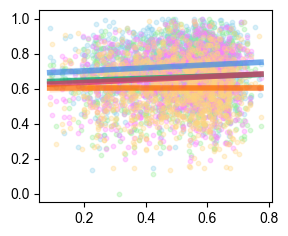

In [590]:

import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
# Set global font to Arial
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
# Synthetic data
# mask = (labelns>10) & (distance_list>0) & (distance_list<0.5)  & same_chapter
# mask = (labelns>1) & (distance_list>0) &  same_chapter
p_mask = ((labelns/subjns)>0.01) & (distance_list>0)
# p_mask = ((labelns/subjns)>0.) & (distance_list>0) & group_vw

plt.figure(figsize=(3, 2.5))
mask = p_mask & (methods == 'DiffDT-Qwen3')
auc_one_plot(distance_list[mask], aucs[mask], labelns[mask], 'skyblue', '#0047AB')
mask = p_mask & (methods == 'DiffDT-GPT2')
auc_one_plot(distance_list[mask], aucs[mask], labelns[mask], 'lightgreen', '#00A36C')
mask = p_mask & (methods == 'Delphi-Qwen3')
auc_one_plot(distance_list[mask], aucs[mask], labelns[mask], '#FF80FF', '#DE3163') # magenta
mask = p_mask & (methods == 'Delphi-GPT2')
auc_one_plot(distance_list[mask], aucs[mask], labelns[mask], '#FFD580', '#FC6A03') # orange
plt.savefig('../StableDiffusion-PyTorch/icml26_fig_exp1_all-data.svg')

-0.21698198171099622 2.9741915501825776e-15
0.09844294010070284
-0.2492124798785861 9.032261790213421e-20
0.06352557434380791
-0.23571693102214455 8.515605958288374e-18
0.0632852685678799
-0.1197515689326909 6.153540866999715e-05
0.05039703267825157


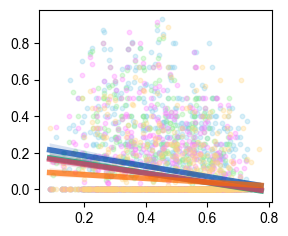

In [644]:

import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
# Set global font to Arial
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
# Synthetic data
# mask = (labelns>10) & (distance_list>0) & (distance_list<0.5)  & same_chapter
# mask = (labelns>1) & (distance_list>0) &  same_chapter
p_mask = ((labelns/subjns)>0.01) & (distance_list>0) #& (f1s>0)
# p_mask = ((labelns/subjns)>0.) & (distance_list>0) & group_vw

plt.figure(figsize=(3, 2.5))
mask = p_mask & (methods == 'DiffDT-Qwen3')
auc_one_plot(distance_list[mask], f1s[mask], labelns[mask], 'skyblue', '#0047AB')
print(np.mean(f1s[mask]))
mask = p_mask & (methods == 'DiffDT-GPT2')
auc_one_plot(distance_list[mask], f1s[mask], labelns[mask], 'lightgreen', '#00A36C')
print(np.mean(f1s[mask]))
mask = p_mask & (methods == 'Delphi-Qwen3')
auc_one_plot(distance_list[mask], f1s[mask], labelns[mask], '#FF80FF', '#DE3163') # magenta
print(np.mean(f1s[mask]))
mask = p_mask & (methods == 'Delphi-GPT2')
auc_one_plot(distance_list[mask], f1s[mask], labelns[mask], '#FFD580', '#FC6A03') # orange
print(np.mean(f1s[mask]))
plt.savefig('../StableDiffusion-PyTorch/icml26_fig_exp1_f1_all-data.svg')

In [520]:

from scipy.stats import ttest_rel, ttest_ind
sortid = [i for i, m in enumerate(methods) if 'Delphi-GPT2' in m] + [i for i, m in enumerate(methods) if 'DiffDT-GPT2' in m] + [i for i, m in enumerate(methods) if 'Delphi-Qwen3' in m] + [i for i, m in enumerate(methods) if 'DiffDT-Qwen3' in m] 


6.645923911943654e-72
6.778155444730148e-32


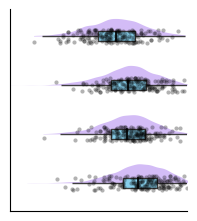

In [597]:
df = pd.DataFrame({'AUC': aucs[sortid], 'Method': methods[sortid]})
# ---- Plot ----
plt.figure(figsize=(3.25,2.75))
ax = sns.violinplot(
    data=df,
    y="Method", x="AUC",
    inner=None, cut=0, linewidth=0,
    bw_adjust=0.8,
    fill=True,
    color="#d1b3ff"  # light purple
)

# ---- Keep only the top half of violins ----
# For horizontal violins, clip so that only upper half (y > center) remains.
for i, artist in enumerate(ax.collections):
    path = artist.get_paths()[0]
    verts = path.vertices
    verts[:, 1] = np.clip(verts[:, 1], i-0.4, i)  # keep top half only

# ---- Overlay boxplot ----
sns.boxplot(
    data=df,
    y="Method", x="AUC",
    width=0.2, showcaps=False,
    boxprops={"facecolor":"#87ceeb", "zorder":3},  # skyblue
    showfliers=False,
    whiskerprops={"linewidth":1},
    ax=ax
)

# ---- Overlay scatter points ----
sns.stripplot(
    data=df.iloc[np.arange(len(df)).tolist()[::10]],
    y="Method", x="AUC",
    size=3, color="k", alpha=0.3,
    jitter=0.15, ax=ax
)
# ---- Mean line (dashed) ----
for i, g in enumerate(df["Method"].unique()):
    mean_val = df.loc[df["Method"] == g, "AUC"].mean()
    ax.plot([mean_val, mean_val], [i - 0.09, i+0.1], color="k", lw=1.2, ls="-", zorder=4)


t, p = ttest_rel(df[df['Method']=='DiffDT-Qwen3']['AUC'].tolist(), df[df['Method']=='Delphi-Qwen3']['AUC'].tolist())
print(p)
t, p = ttest_ind(df[df['Method']=='DiffDT-GPT2']['AUC'].tolist(), df[df['Method']=='Delphi-GPT2']['AUC'].tolist())
print(p)
# ---- Style ----
sns.despine()
# ax.set_title(f"Delphi: {auc_df['auc'].mean()*100:.2f}±{auc_df['auc'].std()*100:.2f} vs BC_E2E: {bc_auc_df['auc'].mean()*100:.2f}±{bc_auc_df['auc'].std()*100:.2f}")
plt.tight_layout()
plt.xlim([0,1])
plt.xticks([])
plt.yticks([])
plt.xlabel('')
plt.ylabel('')
# plt.show()
plt.savefig('../StableDiffusion-PyTorch/icml26_fig_exp1_violin_all-data.svg')

0.004700438529141037
2.670887938857159e-08


(0.0, 1.0)

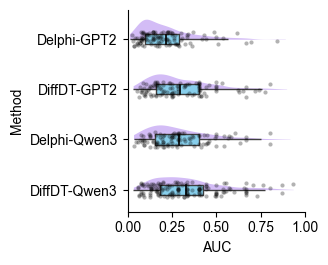

In [652]:
df = pd.DataFrame({'AUC': f1s[sortid], 'Method': methods[sortid]})
df = df[df['AUC']>0]
# ---- Plot ----
plt.figure(figsize=(3.25,2.75))
ax = sns.violinplot(
    data=df,
    y="Method", x="AUC",
    inner=None, cut=0, linewidth=0,
    bw_adjust=0.8,
    fill=True,
    color="#d1b3ff"  # light purple
)

# ---- Keep only the top half of violins ----
# For horizontal violins, clip so that only upper half (y > center) remains.
for i, artist in enumerate(ax.collections):
    path = artist.get_paths()[0]
    verts = path.vertices
    verts[:, 1] = np.clip(verts[:, 1], i-0.4, i)  # keep top half only

# ---- Overlay boxplot ----
sns.boxplot(
    data=df,
    y="Method", x="AUC",
    width=0.2, showcaps=False,
    boxprops={"facecolor":"#87ceeb", "zorder":3},  # skyblue
    showfliers=False,
    whiskerprops={"linewidth":1},
    ax=ax
)

# ---- Overlay scatter points ----
sns.stripplot(
    data=df.iloc[np.arange(len(df)).tolist()[::3]],
    y="Method", x="AUC",
    size=3, color="k", alpha=0.3,
    jitter=0.15, ax=ax
)
# ---- Mean line (dashed) ----
for i, g in enumerate(df["Method"].unique()):
    mean_val = df.loc[df["Method"] == g, "AUC"].mean()
    ax.plot([mean_val, mean_val], [i - 0.09, i+0.1], color="k", lw=1.2, ls="-", zorder=4)


t, p = ttest_ind(df[df['Method']=='DiffDT-Qwen3']['AUC'].tolist(), df[df['Method']=='Delphi-Qwen3']['AUC'].tolist())
print(p)
t, p = ttest_ind(df[df['Method']=='DiffDT-GPT2']['AUC'].tolist(), df[df['Method']=='Delphi-GPT2']['AUC'].tolist())
print(p)
# ---- Style ----
sns.despine()
# ax.set_title(f"Delphi: {auc_df['auc'].mean()*100:.2f}±{auc_df['auc'].std()*100:.2f} vs BC_E2E: {bc_auc_df['auc'].mean()*100:.2f}±{bc_auc_df['auc'].std()*100:.2f}")
plt.tight_layout()
plt.xlim([0,1])
# plt.xticks([])
# plt.yticks([])
# plt.xlabel('')
# plt.ylabel('')
# plt.show()
# plt.savefig('../StableDiffusion-PyTorch/icml26_fig_exp1_f1_violin_all-data.svg')

3.5135862554856735e-13
0.6662174669891512


(0.0, 1.0)

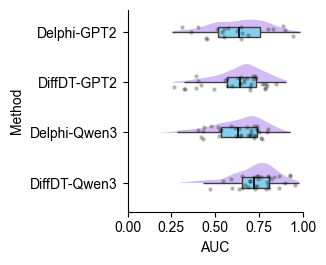

In [648]:
p_mask = ((labelns/subjns)>0.05) & (distance_list>0.4) &  ~same_chapter
# p_mask = ((labelns/subjns)>0.1) & (labelns>5) & (distance_list>0) &  ~same_chapter

df = pd.DataFrame({'AUC': aucs[sortid][p_mask[sortid]], 'Method': methods[sortid][p_mask[sortid]]})
# ---- Plot ----
plt.figure(figsize=(3.25,2.75))
ax = sns.violinplot(
    data=df,
    y="Method", x="AUC",
    inner=None, cut=0, linewidth=0,
    bw_adjust=0.8,
    fill=True,
    color="#d1b3ff"  # light purple
)

# ---- Keep only the top half of violins ----
# For horizontal violins, clip so that only upper half (y > center) remains.
for i, artist in enumerate(ax.collections):
    path = artist.get_paths()[0]
    verts = path.vertices
    verts[:, 1] = np.clip(verts[:, 1], i-0.4, i)  # keep top half only

# ---- Overlay boxplot ----
sns.boxplot(
    data=df,
    y="Method", x="AUC",
    width=0.2, showcaps=False,
    boxprops={"facecolor":"#87ceeb", "zorder":3},  # skyblue
    showfliers=False,
    whiskerprops={"linewidth":1},
    ax=ax
)

# ---- Overlay scatter points ----
sns.stripplot(
    data=df.iloc[np.arange(len(df)).tolist()[::5]],
    y="Method", x="AUC",
    size=3, color="k", alpha=0.3,
    jitter=0.15, ax=ax
)
# ---- Mean line (dashed) ----
for i, g in enumerate(df["Method"].unique()):
    mean_val = df.loc[df["Method"] == g, "AUC"].mean()
    ax.plot([mean_val, mean_val], [i - 0.09, i+0.1], color="k", lw=1.2, ls="-", zorder=4)


t, p = ttest_rel(df[df['Method']=='DiffDT-Qwen3']['AUC'].tolist(), df[df['Method']=='Delphi-Qwen3']['AUC'].tolist())
print(p)
t, p = ttest_ind(df[df['Method']=='DiffDT-GPT2']['AUC'].tolist(), df[df['Method']=='Delphi-GPT2']['AUC'].tolist())
print(p)
# ---- Style ----
sns.despine()
# ax.set_title(f"Delphi: {auc_df['auc'].mean()*100:.2f}±{auc_df['auc'].std()*100:.2f} vs BC_E2E: {bc_auc_df['auc'].mean()*100:.2f}±{bc_auc_df['auc'].std()*100:.2f}")
plt.tight_layout()
plt.xlim([0,1])
# plt.xticks([])
# plt.yticks([])
# plt.xlabel('')
# plt.ylabel('')
# plt.show()
# plt.savefig('../StableDiffusion-PyTorch/icml26_fig_exp1_violin_off-diag.svg')

0.1872427769459333
0.03521346502994604


(0.0, 1.0)

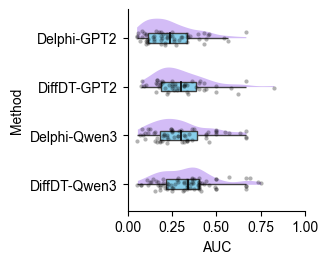

In [654]:
p_mask = ((labelns/subjns)>0.05) & (distance_list>0.4) &  ~same_chapter & (f1s>0)
# p_mask = ((labelns/subjns)>0.1) & (labelns>5) & (distance_list>0) &  ~same_chapter

df = pd.DataFrame({'AUC': f1s[sortid][p_mask[sortid]], 'Method': methods[sortid][p_mask[sortid]]})
# ---- Plot ----
plt.figure(figsize=(3.25,2.75))
ax = sns.violinplot(
    data=df,
    y="Method", x="AUC",
    inner=None, cut=0, linewidth=0,
    bw_adjust=0.8,
    fill=True,
    color="#d1b3ff"  # light purple
)

# ---- Keep only the top half of violins ----
# For horizontal violins, clip so that only upper half (y > center) remains.
for i, artist in enumerate(ax.collections):
    path = artist.get_paths()[0]
    verts = path.vertices
    verts[:, 1] = np.clip(verts[:, 1], i-0.4, i)  # keep top half only

# ---- Overlay boxplot ----
sns.boxplot(
    data=df,
    y="Method", x="AUC",
    width=0.2, showcaps=False,
    boxprops={"facecolor":"#87ceeb", "zorder":3},  # skyblue
    showfliers=False,
    whiskerprops={"linewidth":1},
    ax=ax
)

# ---- Overlay scatter points ----
sns.stripplot(
    data=df.iloc[np.arange(len(df)).tolist()[::1]],
    y="Method", x="AUC",
    size=3, color="k", alpha=0.3,
    jitter=0.15, ax=ax
)
# ---- Mean line (dashed) ----
for i, g in enumerate(df["Method"].unique()):
    mean_val = df.loc[df["Method"] == g, "AUC"].mean()
    ax.plot([mean_val, mean_val], [i - 0.09, i+0.1], color="k", lw=1.2, ls="-", zorder=4)


t, p = ttest_ind(df[df['Method']=='DiffDT-Qwen3']['AUC'].tolist(), df[df['Method']=='Delphi-Qwen3']['AUC'].tolist())
print(p)
t, p = ttest_ind(df[df['Method']=='DiffDT-GPT2']['AUC'].tolist(), df[df['Method']=='Delphi-GPT2']['AUC'].tolist())
print(p)
# ---- Style ----
sns.despine()
# ax.set_title(f"Delphi: {auc_df['auc'].mean()*100:.2f}±{auc_df['auc'].std()*100:.2f} vs BC_E2E: {bc_auc_df['auc'].mean()*100:.2f}±{bc_auc_df['auc'].std()*100:.2f}")
plt.tight_layout()
plt.xlim([0,1])
# plt.xticks([])
# plt.yticks([])
# plt.xlabel('')
# plt.ylabel('')
# plt.show()
# plt.savefig('../StableDiffusion-PyTorch/icml26_fig_exp1_f1_violin_off-diag.svg')

In [500]:
len(df[df['Method']=='DiffDT-GPT2']['AUC'].tolist()), len(df[df['Method']=='Delphi-GPT2']['AUC'].tolist())

(70, 36)

In [ ]:
def auc_violin_one_plot(x, y, label_num, color, color2, alpha=0.3):


Text(0, 0.5, 'AUC')

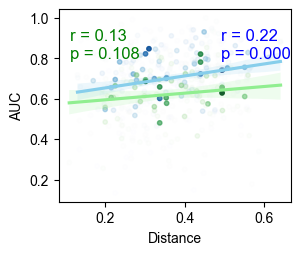

In [264]:

import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
# Set global font to Arial
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
# Synthetic data
# mask = (labelns>10) & (distance_list>0) & (distance_list<0.5)  & same_chapter
# mask = (labelns>1) & (distance_list>0) &  same_chapter
p_mask = ((labelns/subjns)>0.05) & (distance_list>0) &  same_chapter

mask = p_mask & (methods == 'Ours') & (distance_list>distance_list[p_mask & (methods == 'Delphi')].min()) & (distance_list<distance_list[p_mask & (methods == 'Delphi')].max())
x = distance_list[mask]
y = aucs[mask]
label_num = labelns[mask]

# Calculate Pearson correlation
r, p = stats.pearsonr(x, y)

plt.figure(figsize=(3, 2.5))

# 1. Plot regression line (scatter=False avoids color conflict)
sns.regplot(x=x, y=y, scatter=False, line_kws={'color': 'skyblue'})
# 3. Prepare Colors and Alphas
# Normalize label_num for color mapping
norm = mcolors.Normalize(vmin=min(label_num), vmax=max(label_num))
cmap = cm.Blues

# Get RGB colors from colormap
colors = cmap(norm(label_num))

# Calculate custom alpha values (scale to range 0.3 - 1.0)
label_min, label_max = min(label_num), max(label_num)
if label_max > label_min:
    alpha_values = 0.02 + 0.98 * (label_num - label_min) / (label_max - label_min)
else:
    alpha_values = np.ones_like(label_num)
alpha_values = alpha_values.clip(max=1)
# Update alpha channel in the colors array
colors[:, 3] = alpha_values

# 2. Plot scattered dots with color mapping
scatter = plt.scatter(x, y, c=colors, s=10, zorder=-1)

# 3. Annotate Pearson's correlation with Arial font
plt.text(0.7, 0.9, f"r = {r:.2f}\np = {p:.3f}", 
         transform=plt.gca().transAxes, 
         color='blue',
         fontsize=12, 
         fontname='Arial',
         verticalalignment='top')

mask = p_mask & (methods == 'Delphi') & (distance_list>distance_list[p_mask & (methods == 'Ours')].min()) & (distance_list<distance_list[p_mask & (methods == 'Ours')].max())
x = distance_list[mask]
y = aucs[mask]
label_num = labelns[mask]

r, p = stats.pearsonr(x, y)
# 1. Plot regression line (scatter=False avoids color conflict)
sns.regplot(x=x, y=y, scatter=False, line_kws={'color': 'lightgreen'})
# 3. Prepare Colors and Alphas
# Normalize label_num for color mapping
norm = mcolors.Normalize(vmin=min(label_num), vmax=max(label_num))
cmap = cm.Greens

# Get RGB colors from colormap
colors = cmap(norm(label_num))

# Calculate custom alpha values (scale to range 0.3 - 1.0)
label_min, label_max = min(label_num), max(label_num)
if label_max > label_min:
    alpha_values = 0.02 + 0.98 * (label_num - label_min) / (label_max - label_min)
else:
    alpha_values = np.ones_like(label_num)

# Update alpha channel in the colors array
alpha_values = alpha_values.clip(max=1)
colors[:, 3] = alpha_values

# 2. Plot scattered dots with color mapping
scatter = plt.scatter(x, y, c=colors, s=10, zorder=-1)

# 3. Annotate Pearson's correlation with Arial font
plt.text(0.05, 0.9, f"r = {r:.2f}\np = {p:.3f}", 
         transform=plt.gca().transAxes, 
         fontsize=12, 
         color='green',
         fontname='Arial',
         verticalalignment='top')

# sm = cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])
# ax = plt.gca()
# plt.colorbar(sm, ax=ax, label='N(positive)')
plt.xlabel('Distance')
plt.ylabel('AUC')
# plt.savefig('../StableDiffusion-PyTorch/icml26_fig_preliminary1.svg')

Text(0, 0.5, 'AUC')

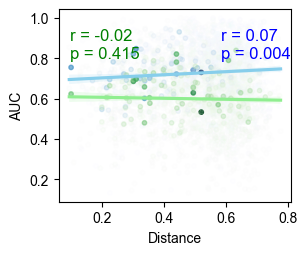

In [152]:

import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
# Set global font to Arial
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
# Synthetic data
# mask = (labelns>10) & (distance_list>0) & (distance_list<0.5)  & same_chapter
# mask = (labelns>1) & (distance_list>0) &  same_chapter
p_mask = (distance_list>0)

mask = p_mask & (methods == 'Ours') & (distance_list>distance_list[p_mask & (methods == 'Delphi')].min())
x = distance_list[mask]
y = aucs[mask]
label_num = labelns[mask]

# Calculate Pearson correlation
r, p = stats.pearsonr(x, y)

plt.figure(figsize=(3, 2.5))

# 1. Plot regression line (scatter=False avoids color conflict)
sns.regplot(x=x, y=y, scatter=False, line_kws={'color': 'skyblue'})
# 3. Prepare Colors and Alphas
# Normalize label_num for color mapping
norm = mcolors.Normalize(vmin=min(label_num), vmax=max(label_num))
cmap = cm.Blues

# Get RGB colors from colormap
colors = cmap(norm(label_num))

# Calculate custom alpha values (scale to range 0.3 - 1.0)
label_min, label_max = min(label_num), max(label_num)
if label_max > label_min:
    alpha_values = 0.02 + 0.98 * (label_num - label_min) / (label_max - label_min)
else:
    alpha_values = np.ones_like(label_num)
alpha_values = alpha_values.clip(max=1)
# Update alpha channel in the colors array
colors[:, 3] = alpha_values

# 2. Plot scattered dots with color mapping
scatter = plt.scatter(x, y, c=colors, s=10, zorder=-1)

# 3. Annotate Pearson's correlation with Arial font
plt.text(0.7, 0.9, f"r = {r:.2f}\np = {p:.3f}", 
         transform=plt.gca().transAxes, 
         color='blue',
         fontsize=12, 
         fontname='Arial',
         verticalalignment='top')

mask = p_mask & (methods == 'Delphi') & (distance_list>distance_list[p_mask & (methods == 'Ours')].min())
x = distance_list[mask]
y = aucs[mask]
label_num = labelns[mask]

r, p = stats.pearsonr(x, y)
# 1. Plot regression line (scatter=False avoids color conflict)
sns.regplot(x=x, y=y, scatter=False, line_kws={'color': 'lightgreen'})
# 3. Prepare Colors and Alphas
# Normalize label_num for color mapping
norm = mcolors.Normalize(vmin=min(label_num), vmax=max(label_num))
cmap = cm.Greens

# Get RGB colors from colormap
colors = cmap(norm(label_num))

# Calculate custom alpha values (scale to range 0.3 - 1.0)
label_min, label_max = min(label_num), max(label_num)
if label_max > label_min:
    alpha_values = 0.02 + 0.98 * (label_num - label_min) / (label_max - label_min)
else:
    alpha_values = np.ones_like(label_num)

# Update alpha channel in the colors array
alpha_values = alpha_values.clip(max=1)
colors[:, 3] = alpha_values

# 2. Plot scattered dots with color mapping
scatter = plt.scatter(x, y, c=colors, s=10, zorder=-1)

# 3. Annotate Pearson's correlation with Arial font
plt.text(0.05, 0.9, f"r = {r:.2f}\np = {p:.3f}", 
         transform=plt.gca().transAxes, 
         fontsize=12, 
         color='green',
         fontname='Arial',
         verticalalignment='top')

# sm = cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])
# ax = plt.gca()
# plt.colorbar(sm, ax=ax, label='N(positive)')
plt.xlabel('Distance')
plt.ylabel('AUC')
# plt.savefig('../StableDiffusion-PyTorch/icml26_fig_preliminary1.svg')

Text(0, 0.5, 'AUC')

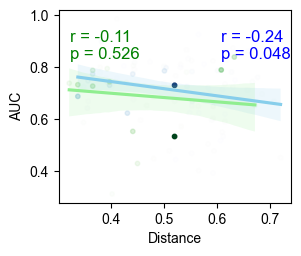

In [154]:

import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
# Set global font to Arial
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
# Synthetic data
# mask = (labelns>10) & (distance_list>0) & (distance_list<0.5)  & same_chapter
# mask = (labelns>1) & (distance_list>0) &  same_chapter
p_mask = ((labelns/subjns)>0.1) & (distance_list>0) &  ~same_chapter

mask = p_mask & (methods == 'Ours') & (distance_list>distance_list[p_mask & (methods == 'Delphi')].min())
x = distance_list[mask]
y = aucs[mask]
label_num = labelns[mask]

# Calculate Pearson correlation
r, p = stats.pearsonr(x, y)

plt.figure(figsize=(3, 2.5))

# 1. Plot regression line (scatter=False avoids color conflict)
sns.regplot(x=x, y=y, scatter=False, line_kws={'color': 'skyblue'})
# 3. Prepare Colors and Alphas
# Normalize label_num for color mapping
norm = mcolors.Normalize(vmin=min(label_num), vmax=max(label_num))
cmap = cm.Blues

# Get RGB colors from colormap
colors = cmap(norm(label_num))

# Calculate custom alpha values (scale to range 0.3 - 1.0)
label_min, label_max = min(label_num), max(label_num)
if label_max > label_min:
    alpha_values = 0.02 + 0.98 * (label_num - label_min) / (label_max - label_min)
else:
    alpha_values = np.ones_like(label_num)
alpha_values = alpha_values.clip(max=1)
# Update alpha channel in the colors array
colors[:, 3] = alpha_values

# 2. Plot scattered dots with color mapping
scatter = plt.scatter(x, y, c=colors, s=10, zorder=-1)

# 3. Annotate Pearson's correlation with Arial font
plt.text(0.7, 0.9, f"r = {r:.2f}\np = {p:.3f}", 
         transform=plt.gca().transAxes, 
         color='blue',
         fontsize=12, 
         fontname='Arial',
         verticalalignment='top')

mask = p_mask & (methods == 'Delphi') & (distance_list>distance_list[p_mask & (methods == 'Ours')].min())
x = distance_list[mask]
y = aucs[mask]
label_num = labelns[mask]

r, p = stats.pearsonr(x, y)
# 1. Plot regression line (scatter=False avoids color conflict)
sns.regplot(x=x, y=y, scatter=False, line_kws={'color': 'lightgreen'})
# 3. Prepare Colors and Alphas
# Normalize label_num for color mapping
norm = mcolors.Normalize(vmin=min(label_num), vmax=max(label_num))
cmap = cm.Greens

# Get RGB colors from colormap
colors = cmap(norm(label_num))

# Calculate custom alpha values (scale to range 0.3 - 1.0)
label_min, label_max = min(label_num), max(label_num)
if label_max > label_min:
    alpha_values = 0.02 + 0.98 * (label_num - label_min) / (label_max - label_min)
else:
    alpha_values = np.ones_like(label_num)

# Update alpha channel in the colors array
alpha_values = alpha_values.clip(max=1)
colors[:, 3] = alpha_values

# 2. Plot scattered dots with color mapping
scatter = plt.scatter(x, y, c=colors, s=10, zorder=-1)

# 3. Annotate Pearson's correlation with Arial font
plt.text(0.05, 0.9, f"r = {r:.2f}\np = {p:.3f}", 
         transform=plt.gca().transAxes, 
         fontsize=12, 
         color='green',
         fontname='Arial',
         verticalalignment='top')

# sm = cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])
# ax = plt.gca()
# plt.colorbar(sm, ax=ax, label='N(positive)')
plt.xlabel('Distance')
plt.ylabel('AUC')
# plt.savefig('../StableDiffusion-PyTorch/icml26_fig_preliminary1.svg')

In [94]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np

import matplotlib.cm as cm
import matplotlib.colors as mcolors

In [95]:
print(sum((labelns>1) & (distance_list>0) &  same_chapter))

715


Text(0, 0.5, 'AUC')

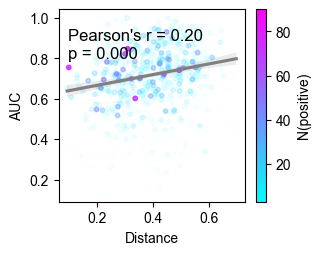

In [96]:

import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
# Set global font to Arial
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
# Synthetic data
# mask = (labelns>10) & (distance_list>0) & (distance_list<0.5)  & same_chapter
mask = (labelns>1) & (distance_list>0) &  same_chapter
x = distance_list[mask]
y = aucs[mask]
label_num = labelns[mask]

# Calculate Pearson correlation
r, p = stats.pearsonr(x, y)

plt.figure(figsize=(3, 2.5))

# 1. Plot regression line (scatter=False avoids color conflict)
sns.regplot(x=x, y=y, scatter=False, line_kws={'color': 'gray'})
# 3. Prepare Colors and Alphas
# Normalize label_num for color mapping
norm = mcolors.Normalize(vmin=min(label_num), vmax=max(label_num))
cmap = cm.cool

# Get RGB colors from colormap
colors = cmap(norm(label_num))

# Calculate custom alpha values (scale to range 0.3 - 1.0)
label_min, label_max = min(label_num), max(label_num)
if label_max > label_min:
    alpha_values = 0.02 + 0.98 * (label_num - label_min) / (label_max - label_min)
else:
    alpha_values = np.ones_like(label_num)

# Update alpha channel in the colors array
colors[:, 3] = alpha_values

# 2. Plot scattered dots with color mapping
scatter = plt.scatter(x, y, c=colors, s=10, zorder=-1)

# 3. Annotate Pearson's correlation with Arial font
plt.text(0.05, 0.9, f"Pearson's r = {r:.2f}\np = {p:.3f}", 
         transform=plt.gca().transAxes, 
         fontsize=12, 
         fontname='Arial',
         verticalalignment='top')

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
ax = plt.gca()
plt.colorbar(sm, ax=ax, label='N(positive)')
plt.xlabel('Distance')
plt.ylabel('AUC')
# plt.savefig('../StableDiffusion-PyTorch/icml26_fig_preliminary1.svg')

In [64]:
print(sum((labelns>1) & (distance_list>=0) & ~same_chapter))

949


Text(0, 0.5, 'AUC')

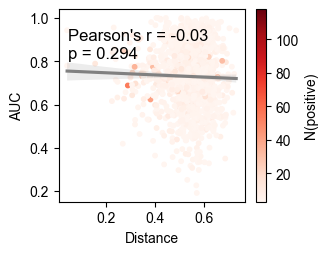

In [97]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
# Set global font to Arial
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
# Synthetic data
mask = (labelns>1) & (distance_list>=0) & ~same_chapter
# mask = (labelns>1) & (distance_list>=0) & (group_vw | group_c) & ~same_chapter
# mask = (labelns>18) & (distance_list>0.5) & ~same_chapter
x = distance_list[mask] - 0.05
y = aucs[mask]
label_num = labelns[mask]

# Calculate Pearson correlation
r, p = stats.pearsonr(x, y)

plt.figure(figsize=(3, 2.5))

# 1. Plot regression line (scatter=False avoids color conflict)
sns.regplot(x=x, y=y, scatter=False, line_kws={'color': 'gray'})

# 2. Plot scattered dots with color mapping
scatter = plt.scatter(x, y, c=label_num, cmap='Reds', s=10, zorder=-1)

# 3. Annotate Pearson's correlation with Arial font
plt.text(0.05, 0.9, f"Pearson's r = {r:.2f}\np = {p:.3f}", 
         transform=plt.gca().transAxes, 
         fontsize=12, 
         fontname='Arial',
         verticalalignment='top')

plt.colorbar(scatter, label='N(positive)')
plt.xlabel('Distance')
plt.ylabel('AUC')
# plt.savefig('../StableDiffusion-PyTorch/icml26_fig_preliminary3.svg')

In [102]:
len(distance_list[(distance_list>0)])

1973

Text(0, 0.5, 'AUC')

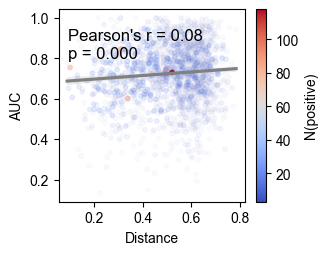

In [99]:

# Set global font to Arial
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
# Synthetic data
x = distance_list[(labelns>1) & (aucs>0.1) & (distance_list>0)]
y = aucs[ (labelns>1) &(aucs>0.1) & (distance_list>0)]
label_num = labelns[(labelns>1) &(aucs>0.1) & (distance_list>0)]

# Calculate Pearson correlation
r, p = stats.pearsonr(x, y)

plt.figure(figsize=(3, 2.5))

# 1. Plot regression line (scatter=False avoids color conflict)
sns.regplot(x=x, y=y, scatter=False, line_kws={'color': 'gray'})

# 3. Prepare Colors and Alphas
# Normalize label_num for color mapping
norm = mcolors.Normalize(vmin=min(label_num), vmax=max(label_num))
cmap = cm.coolwarm

# Get RGB colors from colormap
colors = cmap(norm(label_num))

# Calculate custom alpha values (scale to range 0.3 - 1.0)
label_min, label_max = min(label_num), max(label_num)
if label_max > label_min:
    alpha_values = 0.02 + 0.98 * (label_num - label_min) / (label_max - label_min)
else:
    alpha_values = np.ones_like(label_num)

# Update alpha channel in the colors array
colors[:, 3] = alpha_values

# 2. Plot scattered dots with color mapping
scatter = plt.scatter(x, y, c=colors, s=10, zorder=-1)

# 3. Annotate Pearson's correlation with Arial font
plt.text(0.05, 0.9, f"Pearson's r = {r:.2f}\np = {p:.3f}", 
         transform=plt.gca().transAxes, 
         fontsize=12, 
         fontname='Arial',
         verticalalignment='top')
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
ax = plt.gca()
plt.colorbar(sm, ax=ax, label='N(positive)')
# plt.colorbar(scatter, label='N(event)')
plt.xlabel('Distance')
plt.ylabel('AUC')
# plt.savefig('../StableDiffusion-PyTorch/icml26_fig_preliminary2.svg')

In [100]:
print(sum((labelns>180) & (aucs>0.1) & (distance_list>0)))

0


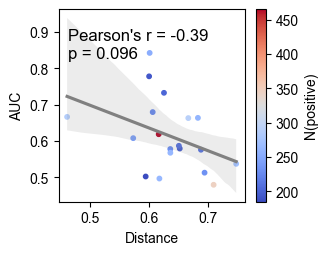

In [485]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import numpy as np
# Set global font to Arial
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
# Synthetic data
x = distance_list[(labelns>180) & (aucs>0.1) & (distance_list>0)]
y = aucs[(labelns>180) & (aucs>0.1) & (distance_list>0)]
label_num = labelns[(labelns>180) & (aucs>0.1) & (distance_list>0)]

# Calculate Pearson correlation
r, p = stats.pearsonr(x, y)

plt.figure(figsize=(3, 2.5))

# 1. Plot regression line (scatter=False avoids color conflict)
sns.regplot(x=x, y=y, scatter=False, line_kws={'color': 'gray'})

# 2. Plot scattered dots with color mapping
scatter = plt.scatter(x, y, c=label_num, cmap='coolwarm', s=10, zorder=-10)

# 3. Annotate Pearson's correlation with Arial font
plt.text(0.05, 0.9, f"Pearson's r = {r:.2f}\np = {p:.3f}", 
         transform=plt.gca().transAxes, 
         fontsize=12, 
         fontname='Arial',
         verticalalignment='top')

plt.colorbar(scatter, label='N(positive)')
plt.xlabel('Distance')
plt.ylabel('AUC')
plt.savefig('../StableDiffusion-PyTorch/icml26_fig_preliminary4.svg')

## Delphi style eval

In [331]:
all_seq_posid.min()

tensor(0, device='cuda:3')

In [ ]:
from sklearn import metrics
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from tqdm import tqdm
all_gt = all_gt.cpu()
all_pred_score = all_pred_score.cpu()
all_pred_id = all_pred_id.cpu()
all_seq_posid = all_seq_posid.cpu()
labeln = []
labels = all_gt.unique().tolist()
auc_list = []
prec_list = []
rec_list = []
f1_list = []
pred_idx = all_pred_score.argmax(-1)
for labeli in tqdm(all_gt.unique()):
    gt = (all_gt == labeli).float()
    if gt.sum() < 2: continue
    pred_score = all_pred_score[:, labeli]
    pred = (pred_idx==labeli).float()
    auc = metrics.roc_auc_score(gt, pred_score)
    prec = precision_score(gt, pred)
    rec = recall_score(gt, pred)
    f1 = f1_score(gt, pred)
    prec_list.append(prec)
    rec_list.append(rec)
    f1_list.append(f1)
    auc_list.append(auc)
    labeln.append(gt.sum())
    # break
# auc, tokenizer_decode(all_gt.unique().tolist())[labeli]